In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('powerplant_data.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop(columns = ['PE'])
y = df['PE']

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)


In [9]:
X_scaled_train

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [10]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_scaled_train , dtype = torch.float32)
X_test_tensor = torch.tensor(X_scaled_test , dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1 ,1)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1 ,1)

In [11]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [12]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_dataset , batch_size = 32)

## Deeplearning


In [35]:
class PowerPlant(nn.Module):
    def __init__(self):
        super(PowerPlant,self).__init__()

        self.model = nn.Sequential(
            #1st layer
            nn.Linear(X_train.shape[1] , 6),
            nn.ReLU(),

            #2nd layer
            nn.Linear(6 , 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6 , 1)
            
        )

    def forward(self , x):
        return self.model(x)
            

In [36]:
import torch.optim as optim

model = PowerPlant()

#Loss function and optimizers
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### Train the model

In [37]:

train_losses = []
#validation losses
val_losses = []

best_model_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb , yb in train_loader:

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs , yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() # to convert tensor to float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation 
    model.eval()
    val_loss = 0.0
    with torch.no_grad():

        for xb , yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs , yb)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"{epoch + 1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")              
        
    
    if epoch_val_loss < best_model_loss:
        best_model_loss = epoch_val_loss

        torch.save(model.state_dict(),"best_model.pt") ##extension pt or pth
    

1/100 ==> train loss = 206540.41236979168 & val loss = 205615.69401041666
2/100 ==> train loss = 202388.02877604167 & val loss = 195156.03984375
3/100 ==> train loss = 177325.24010416667 & val loss = 154322.50859375
4/100 ==> train loss = 125136.95673828125 & val loss = 95894.18580729167
5/100 ==> train loss = 70939.4326985677 & val loss = 50870.22897135417
6/100 ==> train loss = 38501.381616210936 & val loss = 29890.717903645833
7/100 ==> train loss = 24871.183915201822 & val loss = 21117.791878255208
8/100 ==> train loss = 18607.869954427082 & val loss = 16471.363411458333
9/100 ==> train loss = 14736.655228678386 & val loss = 13089.116861979166
10/100 ==> train loss = 11605.23251953125 & val loss = 10074.960774739584
11/100 ==> train loss = 8770.51006418864 & val loss = 7446.147192382812
12/100 ==> train loss = 6412.685339355468 & val loss = 5328.323470052083
13/100 ==> train loss = 4511.650729370117 & val loss = 3689.8485188802083
14/100 ==> train loss = 3062.198191833496 & val los

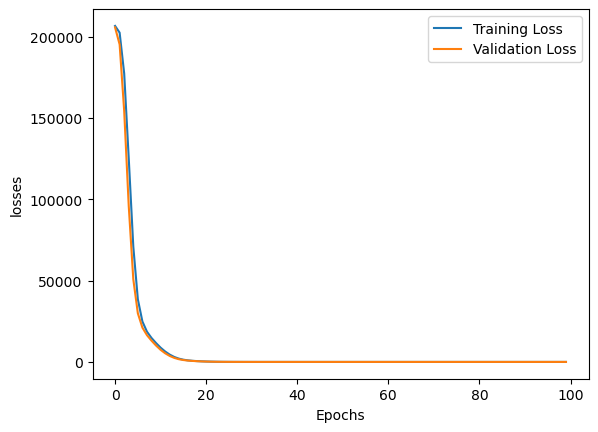

In [38]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss":train_losses,
    "val_loss" : val_losses
})

plt.plot(loss_df["train_loss"] , label = "Training Loss")
plt.plot(loss_df["val_loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("losses")
plt.legend()

## Load the model

In [39]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluate the model

In [45]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_preds , y_train_tensor)
    test_mse_loss = criterion(test_pred , y_test_tensor)

print("Training mse is :" , train_mse_loss.item())
print("Testing mse is : " , test_mse_loss.item())


Training mse is : 21.19100570678711
Testing mse is :  19.59905242919922


In [46]:
from sklearn.metrics import r2_score

print("r2 score is " ,r2_score(y_test , test_pred))

r2 score is  0.9315063772057706


In [48]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

df = pd.concat([predicted_df, actual_df], axis=1)

In [51]:
df.to_csv('Output.csv')